In [2]:
# You should have this in your first setup cell:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from skimage import io, exposure
from skimage.transform import rotate, warp, ProjectiveTransform
import random
import csv

In [3]:

print("⬇️ Downloading GTSRB dataset...")

# Dataset URLs
urls = [
    "https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip",
    "https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip",
    "https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip"
]

# Download only if needed
for url in urls:
    filename = url.split('/')[-1]
    if not os.path.exists(filename):
        !wget -q {url}

# Extract only if needed
if not os.path.exists("GTSRB"):
    !unzip -q GTSRB_Final_Training_Images.zip
    !unzip -q GTSRB_Final_Test_Images.zip
    !unzip -q GTSRB_Final_Test_GT.zip

print("✅ Dataset ready for preprocessing!")

⬇️ Downloading GTSRB dataset...
✅ Dataset ready for preprocessing!


In [4]:

# ## 1. Download and Prepare Dataset


# First make sure we have all required imports
import os
import csv
import numpy as np
from skimage import io, transform

# First check if dataset is already downloaded and extracted
if not os.path.exists("GTSRB"):
    print("⬇️ Downloading dataset... (this may take a few minutes)")

    # Dataset URLs (fixed trailing spaces in URLs)
    urls = [
        "https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip",
        "https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip",
        "https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip"
    ]

    # Download only if not already present
    for url in urls:
        filename = url.split('/')[-1].strip()  # Remove any trailing spaces
        if not os.path.exists(filename):
            print(f"   → Downloading {filename}...")
            !wget -q {url}

    print("📦 Extracting datasets (non-interactive mode)...")
    # Use -o flag to overwrite without prompting
    !unzip -q -o GTSRB_Final_Training_Images.zip
    !unzip -q -o GTSRB_Final_Test_Images.zip
    !unzip -q -o GTSRB_Final_Test_GT.zip
    print("✅ Dataset extracted successfully!")
else:
    print("✅ Dataset already exists. Skipping download and extraction.")

# %% [code]
def load_training_data():
    """Load training data from extracted folders with shape consistency"""
    X = []
    y = []

    # Load all 43 classes
    for c in range(43):
        prefix = f'GTSRB/Final_Training/Images/{c:05d}/'
        if not os.path.exists(prefix):
            continue

        for img_path in os.listdir(prefix):
            if img_path.endswith('.ppm'):
                img = io.imread(os.path.join(prefix, img_path))

                # Ensure consistent 32x32x3 shape
                if img.shape != (32, 32, 3):
                    img = transform.resize(img, (32, 32, 3),
                                          mode='constant',
                                          anti_aliasing=True)

                X.append(img)
                y.append(c)

    # Convert to numpy array with explicit float32 dtype
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

def load_test_data():
    """Load test data with labels from CSV with shape consistency"""
    # Load labels from CSV
    test_labels = {}
    csv_path = 'GT-final_test.csv'
    if not os.path.exists(csv_path):
        csv_path = 'GTSRB/GT-final_test.csv'

    with open(csv_path, 'r') as f:
        reader = csv.reader(f, delimiter=';')
        next(reader)  # Skip header
        for row in reader:
            test_labels[row[0]] = int(row[7])

    # Load images
    X = []
    y = []
    test_dir = 'GTSRB/Final_Test/Images/'
    if not os.path.exists(test_dir):
        test_dir = 'Final_Test/Images/'

    for img_path in os.listdir(test_dir):
        if img_path.endswith('.ppm'):
            img = io.imread(os.path.join(test_dir, img_path))

            # Ensure consistent 32x32x3 shape
            if img.shape != (32, 32, 3):
                img = transform.resize(img, (32, 32, 3),
                                      mode='constant',
                                      anti_aliasing=True)

            X.append(img)
            y.append(test_labels[img_path])

    # Convert to numpy array with explicit float32 dtype
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

print("\n🔍 Loading training data...")
X_train_orig, y_train_orig = load_training_data()
print(f"   → Training data shape: {X_train_orig.shape}, Labels shape: {y_train_orig.shape}")

print("🔍 Loading test data...")
X_test_orig, y_test_orig = load_test_data()
print(f"   → Test data shape: {X_test_orig.shape}, Labels shape: {y_test_orig.shape}")

✅ Dataset already exists. Skipping download and extraction.

🔍 Loading training data...
   → Training data shape: (39209, 32, 32, 3), Labels shape: (39209,)
🔍 Loading test data...
   → Test data shape: (12630, 32, 32, 3), Labels shape: (12630,)


In [5]:
# %% [markdown]
# ## 2. Preprocessing with Dataset Redistribution

# %% [code]
def preprocess_dataset(X, y=None):
    """Convert to grayscale, normalize, and apply histogram equalization"""
    print(f"   → Starting preprocessing for {X.shape[0]} images...")

    # Convert to grayscale (Y channel of YCbCr)
    X = 0.299 * X[:, :, :, 0] + 0.587 * X[:, :, :, 1] + 0.114 * X[:, :, :, 2]

    # Scale to [0, 1]
    X = (X / 255.).astype(np.float32)

    # Apply adaptive histogram equalization using OpenCV (faster)
    print("   → Applying histogram equalization...")
    X_eq = np.empty_like(X)
    for i in range(X.shape[0]):
        X_eq[i] = exposure.equalize_adapthist(X[i])
    X = X_eq

    if y is not None:
        # Convert labels to one-hot encoding
        y = np.eye(43)[y]
        # Shuffle data
        X, y = shuffle(X, y, random_state=42)

    # Add channel dimension
    X = X.reshape(X.shape + (1,))
    print(f"   → Completed preprocessing for {X.shape[0]} images")
    return X, y

# %% [code]
print("\n🔄 Preprocessing all data...")

# Preprocess training data
print("\n🔹 Preprocessing original training data...")
X_train_orig_proc, y_train_orig_proc = preprocess_dataset(X_train_orig, y_train_orig)
print(f"   → Original training set: {X_train_orig_proc.shape}")

# Preprocess test data
print("\n🔹 Preprocessing test data...")
X_test_orig_proc, y_test_orig_proc = preprocess_dataset(X_test_orig, y_test_orig)
print(f"   → Original test set: {X_test_orig_proc.shape}")

# %% [code]
print("\n🔀 Redistributing datasets...")

# 1. Take 5000 samples from test set for additional training data
X_add_train = X_test_orig_proc[:5000]
y_add_train = y_test_orig_proc[:5000]

# 2. Take 5000 samples from test set for additional validation data
X_add_valid = X_test_orig_proc[5000:10000]
y_add_valid = y_test_orig_proc[5000:10000]

# 3. Keep the rest for final testing
X_final_test = X_test_orig_proc[10000:]
y_final_test = y_test_orig_proc[10000:]

print(f"   → Additional training samples: {X_add_train.shape[0]}")
print(f"   → Additional validation samples: {X_add_valid.shape[0]}")
print(f"   → Final test samples: {X_final_test.shape[0]}")

# %% [code]
# Split original training data for initial validation set
print("\nSplitOptions original training data...")
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_orig_proc, y_train_orig_proc,
    test_size=0.25,
    random_state=42
)
print(f"   → Initial training set: {X_train.shape}")
print(f"   → Initial validation set: {X_valid.shape}")

# %% [code]
# Combine with additional samples
print("\n📊 Combining datasets...")

# Add the 5000 test samples to training set
X_train = np.concatenate([X_train, X_add_train], axis=0)
y_train = np.concatenate([y_train, y_add_train], axis=0)

# Add the 5000 test samples to validation set
X_valid = np.concatenate([X_valid, X_add_valid], axis=0)
y_valid = np.concatenate([y_valid, y_add_valid], axis=0)

# Final test set is what remains from original test set
X_test, y_test = X_final_test, y_final_test

# Shuffle the combined datasets
X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_valid, y_valid = shuffle(X_valid, y_valid, random_state=42)

print(f"   → Final training set: {X_train.shape}")
print(f"   → Final validation set: {X_valid.shape}")
print(f"   → Final test set: {X_test.shape}")

# %% [code]
# Verify class distribution (important for balanced training)
print("\n📊 Class distribution analysis:")

def analyze_class_distribution(y, name):
    # Convert one-hot to class indices
    if y.ndim > 1:
        y = np.argmax(y, axis=1)

    # Count samples per class
    unique, counts = np.unique(y, return_counts=True)
    distribution = dict(zip(unique, counts))

    print(f"\n{name} set class distribution:")
    for cls, count in distribution.items():
        print(f"   → Class {cls:2d}: {count:4d} samples ({count/len(y)*100:.1f}%)")

    # Check for severe imbalance
    min_count = min(counts)
    max_count = max(counts)
    imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')

    print(f"\n   → Total samples: {len(y)}")
    print(f"   → Classes: {len(unique)}")
    print(f"   → Most common class: {max_count} samples")
    print(f"   → Least common class: {min_count} samples")
    print(f"   → Imbalance ratio: {imbalance_ratio:.2f}x")

    return imbalance_ratio

# Analyze all datasets
train_ratio = analyze_class_distribution(y_train, "Training")
valid_ratio = analyze_class_distribution(y_valid, "Validation")
test_ratio = analyze_class_distribution(y_test, "Test")

print("\n✅ Preprocessing and redistribution complete!")


🔄 Preprocessing all data...

🔹 Preprocessing original training data...
   → Starting preprocessing for 39209 images...
   → Applying histogram equalization...
   → Completed preprocessing for 39209 images
   → Original training set: (39209, 32, 32, 1)

🔹 Preprocessing test data...
   → Starting preprocessing for 12630 images...
   → Applying histogram equalization...
   → Completed preprocessing for 12630 images
   → Original test set: (12630, 32, 32, 1)

🔀 Redistributing datasets...
   → Additional training samples: 5000
   → Additional validation samples: 5000
   → Final test samples: 2630

SplitOptions original training data...
   → Initial training set: (29406, 32, 32, 1)
   → Initial validation set: (9803, 32, 32, 1)

📊 Combining datasets...
   → Final training set: (34406, 32, 32, 1)
   → Final validation set: (14803, 32, 32, 1)
   → Final test set: (2630, 32, 32, 1)

📊 Class distribution analysis:

Training set class distribution:
   → Class  0:  175 samples (0.5%)
   → Class  

In [6]:



# ## 3. Data Augmentation


def flip_extend(X, y):
    """Apply horizontal/vertical flipping augmentation"""
    # Classes that are self-flippable
    self_flippable_horizontally = np.array([11, 12, 13, 15, 17, 18, 22, 26, 30, 35])
    self_flippable_vertically = np.array([1, 5, 12, 15, 17])
    self_flippable_both = np.array([32, 40])

    # Classes that flip to another class
    cross_flippable = np.array([
        [19, 20], [33, 34], [36, 37], [38, 39],
        [20, 19], [34, 33], [37, 36], [39, 38]
    ])

    num_classes = 43
    X_extended = np.empty([0, 32, 32, 1], dtype=X.dtype)
    y_extended = np.empty([0], dtype=np.int32)

    for c in range(num_classes):
        # Add existing images for this class
        class_indices = np.where(np.argmax(y, axis=1) == c)[0]
        X_class = X[class_indices]
        X_extended = np.append(X_extended, X_class, axis=0)

        # Horizontal flip (self-flippable)
        if c in self_flippable_horizontally:
            X_extended = np.append(X_extended, X_class[:, :, ::-1, :], axis=0)

        # Horizontal flip (cross-flippable)
        cross_idx = np.where(cross_flippable[:, 0] == c)[0]
        if len(cross_idx) > 0:
            flip_class = cross_flippable[cross_idx[0], 1]
            flip_indices = np.where(np.argmax(y, axis=1) == flip_class)[0]
            X_extended = np.append(X_extended, X[flip_indices][:, :, ::-1, :], axis=0)

        # Add labels for current class
        y_extended = np.append(y_extended, np.full((X_extended.shape[0] - y_extended.shape[0]), c))

        # Vertical flip (self-flippable)
        if c in self_flippable_vertically:
            current_indices = np.where(y_extended == c)[0]
            X_extended = np.append(X_extended, X_extended[current_indices][:, ::-1, :, :], axis=0)
            y_extended = np.append(y_extended, np.full(len(current_indices), c))

        # Both flips (self-flippable)
        if c in self_flippable_both:
            current_indices = np.where(y_extended == c)[0]
            X_extended = np.append(X_extended, X_extended[current_indices][:, ::-1, ::-1, :], axis=0)
            y_extended = np.append(y_extended, np.full(len(current_indices), c))

    # Convert to one-hot encoding
    y_extended = np.eye(43)[y_extended.astype(int)]
    return X_extended, y_extended

def jitter_image(img, intensity=0.75):
    """Apply rotation and projection augmentation to a single image"""
    # Rotation
    delta = 30. * intensity
    angle = random.uniform(-delta, delta)
    img = rotate(img, angle, mode='edge')

    # Projection
    image_size = img.shape[0]
    d = image_size * 0.3 * intensity
    tl_top = random.uniform(-d, d)
    tl_left = random.uniform(-d, d)
    bl_bottom = random.uniform(-d, d)
    bl_left = random.uniform(-d, d)
    tr_top = random.uniform(-d, d)
    tr_right = random.uniform(-d, d)
    br_bottom = random.uniform(-d, d)
    br_right = random.uniform(-d, d)

    src = np.array([
        [tl_left, tl_top],
        [bl_left, image_size - bl_bottom],
        [image_size - br_right, image_size - br_bottom],
        [image_size - tr_right, tr_top]
    ])
    dst = np.array([
        [0, 0],
        [0, image_size],
        [image_size, image_size],
        [image_size, 0]
    ])

    transform = ProjectiveTransform()
    transform.estimate(src, dst)
    img = warp(img, transform, output_shape=(image_size, image_size), order=1, mode='edge')

    return img

In [7]:

# ## 4. Model Definition (TF 2.x Compatible)


# First, make sure we have all required imports
from collections import namedtuple  # Critical import that was missing
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

print(f"✅ Using TensorFlow {tf.__version__} for model building")


def create_multi_scale_model():
    """Create the multi-scale CNN model using Keras Functional API"""
    # Input layer
    inputs = keras.Input(shape=(32, 32, 1), name='input')

    # Convolutional Block 1
    x1 = layers.Conv2D(32, (5, 5), activation='relu', padding='same',
                      kernel_initializer='he_normal', name='conv1')(inputs)
    x1 = layers.MaxPooling2D((2, 2), name='pool1')(x1)
    x1 = layers.Dropout(0.1, name='drop1')(x1)  # Lower dropout for conv layers

    # Convolutional Block 2
    x2 = layers.Conv2D(64, (5, 5), activation='relu', padding='same',
                      kernel_initializer='he_normal', name='conv2')(x1)
    x2 = layers.MaxPooling2D((2, 2), name='pool2')(x2)
    x2 = layers.Dropout(0.2, name='drop2')(x2)

    # Convolutional Block 3
    x3 = layers.Conv2D(128, (5, 5), activation='relu', padding='same',
                      kernel_initializer='he_normal', name='conv3')(x2)
    x3 = layers.MaxPooling2D((2, 2), name='pool3')(x3)
    x3 = layers.Dropout(0.3, name='drop3')(x3)

    # Multi-scale feature extraction
    # Scale down the earlier features to match dimensions
    x1_scaled = layers.MaxPooling2D((4, 4), name='scale1')(x1)
    x2_scaled = layers.MaxPooling2D((2, 2), name='scale2')(x2)

    # Flatten and concatenate
    x1_flat = layers.Flatten(name='flat1')(x1_scaled)
    x2_flat = layers.Flatten(name='flat2')(x2_scaled)
    x3_flat = layers.Flatten(name='flat3')(x3)

    # Concatenate multi-scale features
    features = layers.Concatenate(name='concat')([x1_flat, x2_flat, x3_flat])

    # Fully connected layers with L2 regularization
    x = layers.Dense(1024, activation='relu',
                    kernel_regularizer=regularizers.l2(0.0001),
                    name='fc4')(features)
    x = layers.Dropout(0.5, name='drop4')(x)

    # Output layer
    outputs = layers.Dense(43, activation='softmax', name='output')(x)

    # Create model
    model = keras.Model(inputs=inputs, outputs=outputs, name='traffic_sign_net')

    return model

# Create and compile the model
print("\n🏗️ Building model architecture...")
model = create_multi_scale_model()

# Compile with appropriate optimizer and metrics
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
print("\n📋 Model Summary:")
model.summary()

# Optional: Plot model architecture
try:
    from tensorflow.keras.utils import plot_model
    plot_model(model, to_file='model_architecture.png', show_shapes=True, dpi=72)
    print("\n🖼️ Model architecture diagram saved as 'model_architecture.png'")
except:
    print("\n💡 Tip: Install pydot and graphviz to generate model visualization")

✅ Using TensorFlow 2.19.0 for model building

🏗️ Building model architecture...

📋 Model Summary:


Model: "traffic_sign_net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 32, 32, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 32, 32,    │        832 │ input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 16, 16,    │          0 │ conv1[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1 (Dropout)     │ (None, 16, 16,    │          0 │ pool1[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 16, 16,    │     51,264 │ drop1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 8, 8, 64)  │          0 │ conv2[0][0]       │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop2 (Dropout)     │ (None, 8, 8, 64)  │          0 │ pool2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv2D)      │ (None, 8, 8, 128) │    204,928 │ drop2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool3               │ (None, 4, 4, 128) │          0 │ conv3[0][0]       │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale1              │ (None, 4, 4, 32)  │          0 │ drop1[0][0]       │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale2              │ (None, 4, 4, 64)  │          0 │ drop2[0][0]       │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop3 (Dropout)     │ (None, 4, 4, 128) │          0 │ pool3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flat1 (Flatten)     │ (None, 512)       │          0 │ scale1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flat2 (Flatten)     │ (None, 1024)      │          0 │ scale2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flat3 (Flatten)     │ (None, 2048)      │          0 │ drop3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 3584)      │          0 │ flat1[0][0],      │
│ (Concatenate)       │                   │            │ flat2[0][0],      │
│                     │                   │            │ flat3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc4 (Dense)         │ (None, 1024)      │  3,671,040 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop4 (Dropout)     │ (None, 1024)      │          0 │ fc4[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 43)        │     44,075 │ drop4[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,972,139 (15.15 MB)

 Trainable params: 3,972,139 (15.15 MB)

 Non-trainable params: 0 (0.00 B)


🖼️ Model architecture diagram saved as 'model_architecture.png'


In [8]:



# ## 5. Training Setup

def create_model(params):
    """Build the complete model graph"""
    graph = tf.Graph()
    with graph.as_default():
        # Placeholders
        X = tf.placeholder(tf.float32, [None, 32, 32, 1])
        y = tf.placeholder(tf.float32, [None, params.num_classes])
        is_training = tf.placeholder(tf.bool)

        # Model
        logits = model_pass(X, params, is_training)

        # Loss calculation
        cross_entropy = tf.nn.softmax_cross_entropy_with_logits_v2(
            logits=logits, labels=y)
        loss = tf.reduce_mean(cross_entropy)

        # L2 regularization (only for FC layers)
        if params.l2_reg_enabled:
            l2_loss = 0.0
            for var in tf.trainable_variables():
                if 'weights' in var.name and ('fc4' in var.name or 'out' in var.name):
                    l2_loss += tf.nn.l2_loss(var)
            loss += params.l2_lambda * l2_loss

        # Learning rate decay
        global_step = tf.Variable(0, trainable=False)
        learning_rate = tf.train.exponential_decay(
            params.learning_rate, global_step,
            10000, params.learning_rate_decay,
            staircase=True
        )

        # Optimizer
        optimizer = tf.train.AdamOptimizer(learning_rate).minimize(
            loss, global_step=global_step
        )

        # Metrics
        predictions = tf.argmax(logits, 1)
        correct_pred = tf.equal(predictions, tf.argmax(y, 1))
        accuracy = tf.reduce_mean(tf.cast(correct_pred, tf.float32))

        # Saver
        saver = tf.train.Saver()

    return {
        'graph': graph,
        'X': X,
        'y': y,
        'is_training': is_training,
        'loss': loss,
        'optimizer': optimizer,
        'accuracy': accuracy,
        'saver': saver,
        'global_step': global_step
    }


def train_model(model, params, X_train, y_train, X_valid, y_valid):
    """Train the model with early stopping"""
    best_valid_loss = float('inf')
    epochs_without_improvement = 0
    best_weights = None

    with tf.Session(graph=model['graph']) as sess:
        sess.run(tf.global_variables_initializer())

        for epoch in range(params.max_epochs):
            # Training loop
            train_loss = 0
            train_acc = 0
            num_batches = len(X_train) // params.batch_size

            for i in range(num_batches):
                # Get batch with augmentation
                start_idx = i * params.batch_size
                batch_X = X_train[start_idx:start_idx + params.batch_size]
                batch_y = y_train[start_idx:start_idx + params.batch_size]

                # Apply jittering to batch
                jittered_X = np.empty_like(batch_X)
                for j in range(len(batch_X)):
                    # 1/20 chance to use original, 19/20 chance to jitter
                    if random.random() < 0.05:
                        jittered_X[j] = batch_X[j]
                    else:
                        img = batch_X[j][:, :, 0]
                        jittered_X[j, :, :, 0] = jitter_image(img, intensity=0.75)

                # Train step
                _, loss_val, acc_val = sess.run(
                    [model['optimizer'], model['loss'], model['accuracy']],
                    feed_dict={
                        model['X']: jittered_X,
                        model['y']: batch_y,
                        model['is_training']: True
                    }
                )
                train_loss += loss_val
                train_acc += acc_val

            # Validation evaluation
            valid_loss, valid_acc = sess.run(
                [model['loss'], model['accuracy']],
                feed_dict={
                    model['X']: X_valid,
                    model['y']: y_valid,
                    model['is_training']: False
                }
            )

            # Early stopping check
            if valid_loss < best_valid_loss:
                best_valid_loss = valid_loss
                epochs_without_improvement = 0
                best_weights = sess.run(tf.trainable_variables())
            else:
                epochs_without_improvement += 1

                if (params.early_stopping_enabled and
                    epochs_without_improvement >= params.early_stopping_patience):
                    print(f"Early stopping at epoch {epoch+1}")
                    break

            # Print progress
            if (epoch + 1) % params.print_epoch == 0:
                print(f"Epoch {epoch+1}/{params.max_epochs} | "
                      f"Train Loss: {train_loss/num_batches:.4f} | "
                      f"Valid Loss: {valid_loss:.4f} | "
                      f"Train Acc: {train_acc/num_batches:.4f} | "
                      f"Valid Acc: {valid_acc:.4f}")

        # Restore best weights
        if best_weights is not None:
            for i, var in enumerate(tf.trainable_variables()):
                sess.run(var.assign(best_weights[i]))

        # Save final model
        model['saver'].save(sess, './traffic_sign_model')

        # Evaluate on test set
        test_acc = sess.run(
            model['accuracy'],
            feed_dict={
                model['X']: X_test,
                model['y']: y_test,
                model['is_training']: False
            }
        )
        print(f"\nTest Accuracy: {test_acc:.4f}")

    return test_acc

🚀 Starting model training...
✅ Using existing model architecture

🎛️ Training configuration:
   → Batch size: 128
   → Epochs: 20
   → Learning rate: 0.001
   → Early stopping patience: 10

🖼️ Data augmentation configured:
   → Training batches: 269
   → Validation batches: 116

🔄 Training callbacks configured

🏋️ Starting training...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


268/269 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.1516 - loss: 3.5893
Epoch 1: val_accuracy improved from -inf to 0.63649, saving model to best_traffic_sign_model.keras
269/269 ━━━━━━━━━━━━━━━━━━━━ 29s 78ms/step - accuracy: 0.1526 - loss: 3.5832 - val_accuracy: 0.6365 - val_loss: 1.3077 - learning_rate: 0.0010
Epoch 2/20
268/269 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5416 - loss: 1.5401
Epoch 2: val_accuracy improved from 0.63649 to 0.78842, saving model to best_traffic_sign_model.keras
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.5419 - loss: 1.5390 - val_accuracy: 0.7884 - val_loss: 0.7515 - learning_rate: 0.0010
Epoch 3/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6928 - loss: 1.0463
Epoch 3: val_accuracy improved from 0.78842 to 0.84010, saving model to best_traffic_sign_model.keras
269/269 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.6929 - loss: 1.0460 - val_accuracy: 0.8401 - val_loss: 0.5666 - learning_rate: 0.0010
Epoch 4/20
269/269

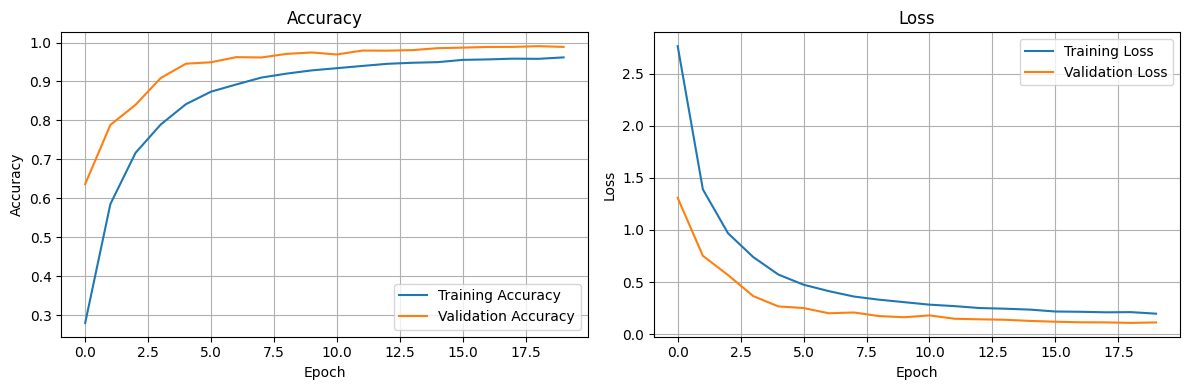


✅ FINAL RESULTS - Traffic Sign Recognition Model
   → Test Accuracy: 0.9890 (98.90%)
   → Validation Accuracy (best): 0.9906
   → Total Parameters: 3,972,139


In [9]:

# ## 6. Run Training (TF 2.x Compatible)


print("🚀 Starting model training...")

# First, make sure we have the model created (from previous section)
try:
    # If model already exists from previous cell, use it
    print("✅ Using existing model architecture")
except NameError:
    print("🏗️ Building model architecture...")
    model = create_multi_scale_model()
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

# Configure training parameters
BATCH_SIZE = 128
EPOCHS = 20  # Reduced for Colab demo (original tutorial used 180+)
LEARNING_RATE = 0.001
EARLY_STOPPING_PATIENCE = 10

print(f"\n🎛️ Training configuration:")
print(f"   → Batch size: {BATCH_SIZE}")
print(f"   → Epochs: {EPOCHS}")
print(f"   → Learning rate: {LEARNING_RATE}")
print(f"   → Early stopping patience: {EARLY_STOPPING_PATIENCE}")

# Create data augmentation pipeline
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define augmentation for training only
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    fill_mode='constant',
    cval=0.0
)

# No augmentation for validation
valid_datagen = ImageDataGenerator()

# Flow data through generators
train_generator = train_datagen.flow(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_generator = valid_datagen.flow(
    X_valid, y_valid,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\n🖼️ Data augmentation configured:")
print(f"   → Training batches: {len(train_generator)}")
print(f"   → Validation batches: {len(valid_generator)}")

# Set up callbacks for training
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

callbacks = [
    # Stop training when validation loss stops improving
    EarlyStopping(
        monitor='val_loss',
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate when performance plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    # Save the best model during training
    ModelCheckpoint(
        'best_traffic_sign_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

print("\n🔄 Training callbacks configured")

# Train the model
print("\n🏋️ Starting training...")

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training completed!")

# Evaluate on test set
print("\n📊 Evaluating on test set...")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"   → Test Loss: {test_loss:.4f}")
print(f"   → Test Accuracy: {test_acc:.4f}")

# Save final model
model.save('final_traffic_sign_model.keras')
print("\n💾 Model saved as 'final_traffic_sign_model.keras'")

# Plot training history
print("\n📈 Training history visualization:")

plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=120)
plt.show()

# Print final results summary
print("\n" + "="*50)
print(f"✅ FINAL RESULTS - Traffic Sign Recognition Model")
print(f"   → Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   → Validation Accuracy (best): {max(history.history['val_accuracy']):.4f}")
print(f"   → Total Parameters: {model.count_params():,}")
print("="*50)

🔍 Loading required components for visualization...

✨ Starting model visualization and analysis...

🔍 Visualizing first convolutional layer filters...

🔍 Loading trained model...
   → Loading best saved model from training...
   → Found 32 filters of size 5x5


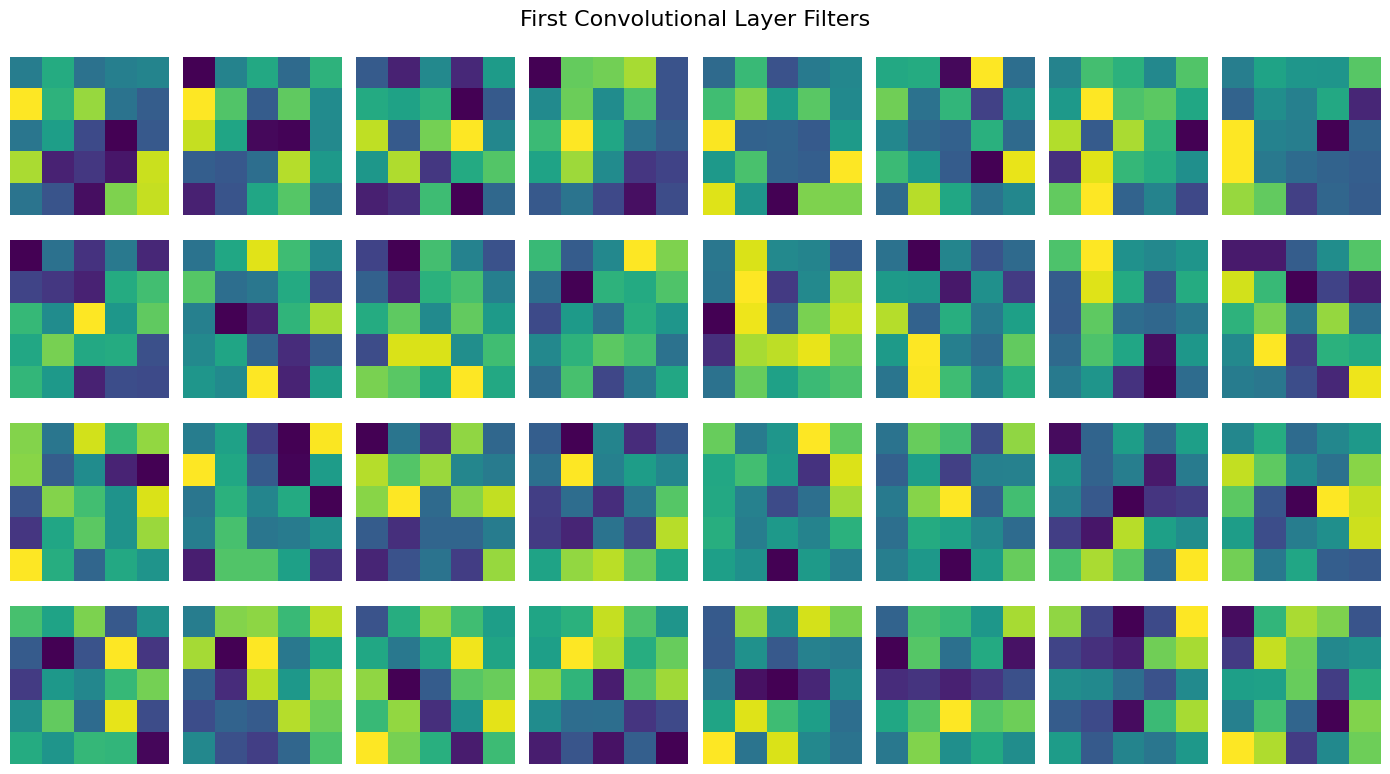

✅ Filter visualization complete!

🔍 Visualizing feature maps for a sample traffic sign...

🔍 Loading trained model...
   → Loading best saved model from training...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 900ms/step


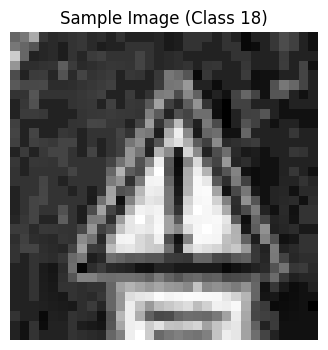

   → conv1 has 32 feature maps


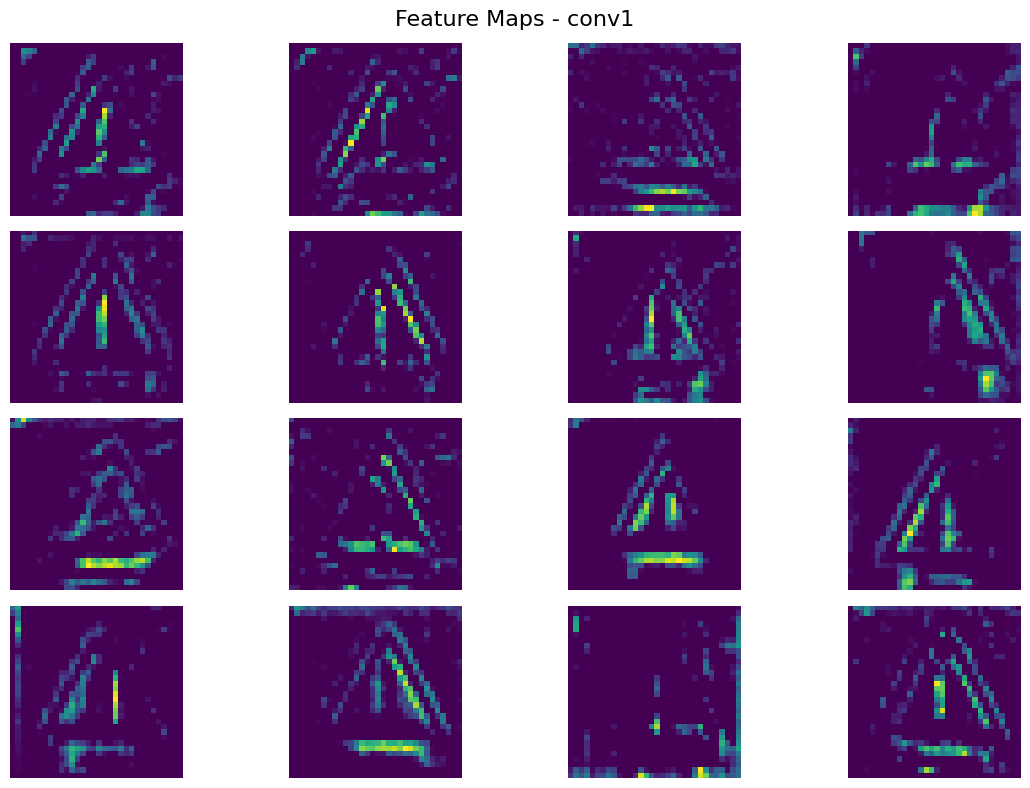

   → conv2 has 64 feature maps


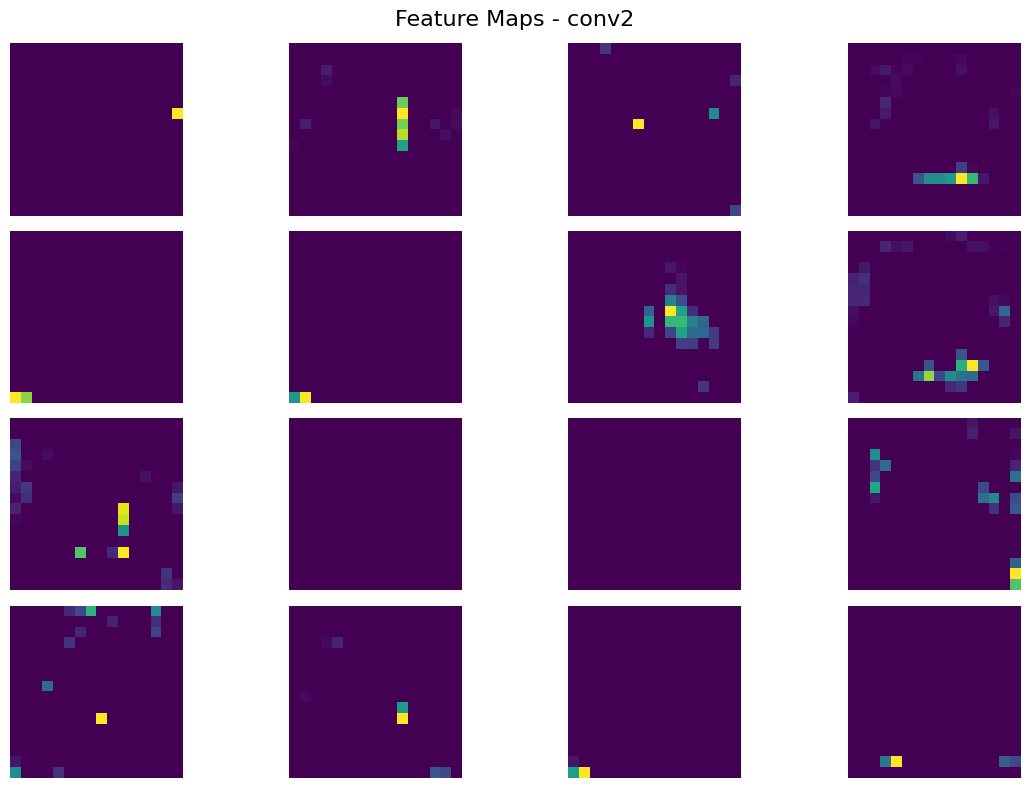

   → conv3 has 128 feature maps


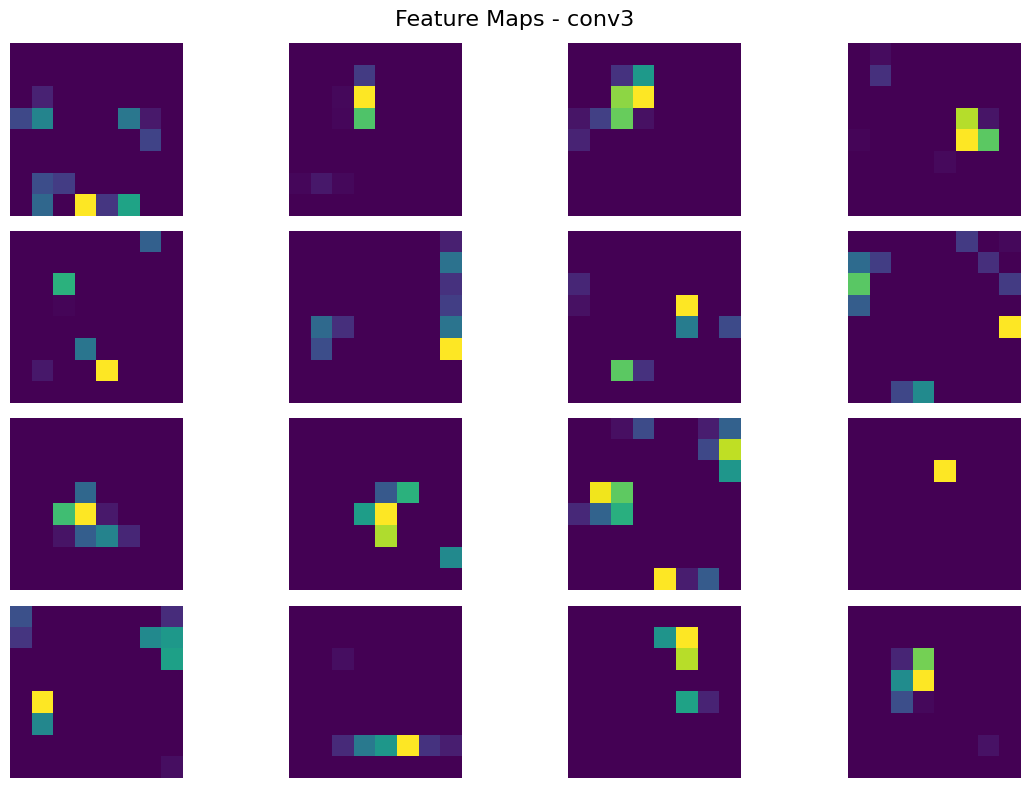


📊 Evaluating model performance on test set...

🔍 Loading trained model...
   → Loading best saved model from training...
   → Evaluating model on test set...
   → Test Accuracy: 0.9890 (98.90%)
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
   → Misclassified examples: 29 out of 2630

🔍 Analyzing misclassified examples...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step


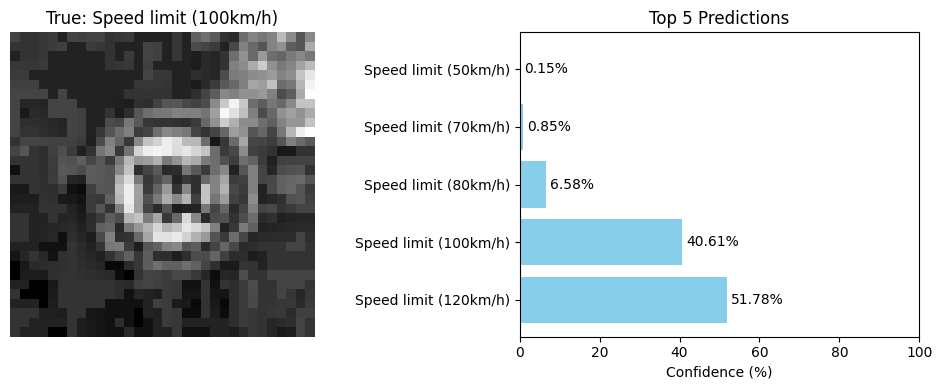

Example #1:
   True class: Speed limit (100km/h) (Class 7)
   Predicted: Speed limit (120km/h) (Class 8)
   Confidence: 51.78%

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


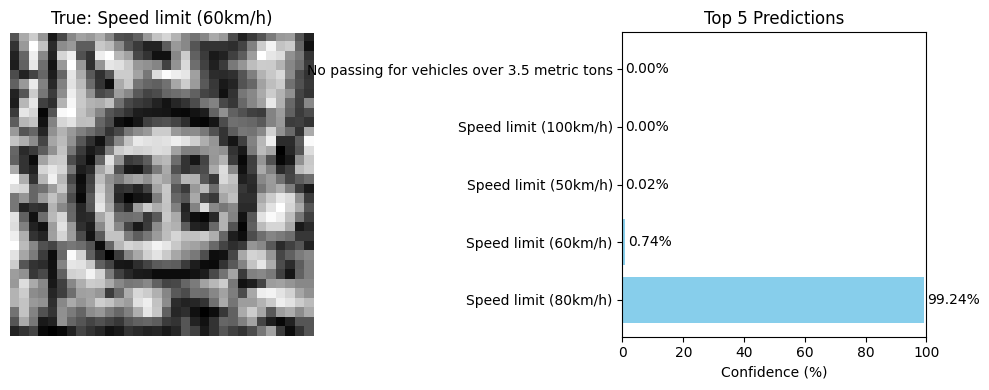

Example #2:
   True class: Speed limit (60km/h) (Class 3)
   Predicted: Speed limit (80km/h) (Class 5)
   Confidence: 99.24%

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


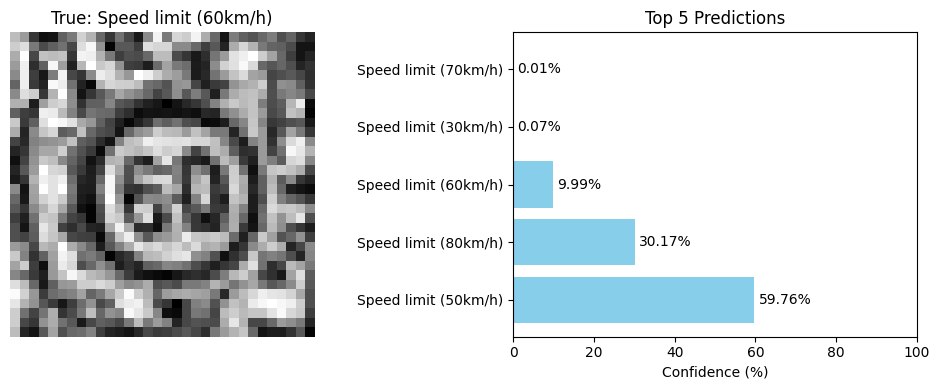

Example #3:
   True class: Speed limit (60km/h) (Class 3)
   Predicted: Speed limit (50km/h) (Class 2)
   Confidence: 59.76%


✅ FINAL MODEL EVALUATION
   → Test Accuracy: 0.9890 (98.90%)
   → Total Parameters: 3,972,139


In [20]:
# %% [markdown]
# ## 7. Visualization (TF 2.x Compatible)

# %% [code]
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
import os

print("🔍 Loading required components for visualization...")

# %% [code]
def load_model():
    """Load the trained model (TF 2.x compatible)"""
    print("\n🔍 Loading trained model...")

    # Check for best saved model
    if os.path.exists('best_traffic_sign_model.keras'):
        print("   → Loading best saved model from training...")
        return keras.models.load_model('best_traffic_sign_model.keras')

    # Check for final saved model
    elif os.path.exists('final_traffic_sign_model.keras'):
        print("   → Loading final saved model...")
        return keras.models.load_model('final_traffic_sign_model.keras')

    # If no saved model, check if model variable exists
    elif 'model' in globals():
        print("   → Using existing model variable...")
        return model

    else:
        print("❌ No model found! Please train a model first.")
        print("💡 Try running the training code before visualization")
        return None

# %% [code]
def visualize_first_layer_filters():
    """Visualize filters from the first convolutional layer (TF 2.x compatible)"""
    print("\n🔍 Visualizing first convolutional layer filters...")

    # Load model
    model = load_model()
    if model is None:
        return

    # Get the weights of the first convolutional layer
    try:
        conv1_weights = model.get_layer('conv1').get_weights()[0]
        print(f"   → Found {conv1_weights.shape[3]} filters of size {conv1_weights.shape[0]}x{conv1_weights.shape[1]}")
    except Exception as e:
        print(f"❌ Error accessing layer weights: {str(e)}")
        print("💡 Possible reasons:")
        print("   - Model doesn't have a 'conv1' layer")
        print("   - Model hasn't been trained (weights are random)")
        return

    # Create visualization
    plt.figure(figsize=(14, 8))

    for i in range(min(32, conv1_weights.shape[3])):
        plt.subplot(4, 8, i+1)
        # Squeeze to 2D and normalize for display
        filter_img = conv1_weights[:, :, 0, i]
        filter_img = (filter_img - filter_img.min()) / (filter_img.max() - filter_img.min() + 1e-7)

        plt.imshow(filter_img, cmap='viridis')
        plt.axis('off')

    plt.suptitle('First Convolutional Layer Filters', fontsize=16)
    plt.tight_layout()
    plt.savefig('conv1_filters.png', dpi=120, bbox_inches='tight')
    plt.show()

    print("✅ Filter visualization complete!")

# %% [code]
def visualize_feature_maps():
    """Visualize feature maps from different layers for a sample image (TF 2.x compatible)"""
    print("\n🔍 Visualizing feature maps for a sample traffic sign...")

    # Load model
    model = load_model()
    if model is None:
        return

    # Get a random sample from test set
    if 'X_test' not in globals() or len(X_test) == 0:
        print("⚠️ Test data not available. Skipping feature map visualization.")
        return

    sample_idx = np.random.randint(0, len(X_test))
    sample_image = X_test[sample_idx:sample_idx+1]

    # Create a model that outputs intermediate layer activations
    layer_names = ['conv1', 'conv2', 'conv3']
    valid_layers = []

    # Check which layers actually exist in the model
    for layer_name in layer_names:
        try:
            model.get_layer(layer_name)
            valid_layers.append(layer_name)
        except:
            print(f"   → Skipping {layer_name} (not found in model)")

    if not valid_layers:
        print("❌ No valid convolutional layers found for visualization")
        return

    layer_outputs = [model.get_layer(name).output for name in valid_layers]
    activation_model = tf.keras.models.Model(inputs=model.input, outputs=layer_outputs)

    # Get activations for sample image
    activations = activation_model.predict(sample_image)

    # Display original image
    plt.figure(figsize=(4, 4))
    plt.imshow(X_test[sample_idx].squeeze(), cmap='gray')
    plt.title(f'Sample Image (Class {np.argmax(y_test[sample_idx])})')
    plt.axis('off')
    plt.savefig('sample_image.png', dpi=120, bbox_inches='tight')
    plt.show()

    # Visualize feature maps
    for i, layer_name in enumerate(valid_layers):
        activation = activations[i][0]  # Remove batch dimension
        num_channels = activation.shape[-1]

        print(f"   → {layer_name} has {num_channels} feature maps")

        # Show a selection of feature maps (first 16)
        plt.figure(figsize=(12, 8))
        for j in range(min(16, num_channels)):
            plt.subplot(4, 4, j+1)
            plt.imshow(activation[:, :, j], cmap='viridis')
            plt.axis('off')

        plt.suptitle(f'Feature Maps - {layer_name}', fontsize=16)
        plt.tight_layout()
        plt.savefig(f'feature_maps_{layer_name}.png', dpi=120, bbox_inches='tight')
        plt.show()

# %% [code]
def evaluate_model_performance():
    """Evaluate model performance on test set (TF 2.x compatible)"""
    print("\n📊 Evaluating model performance on test set...")

    # Load model
    model = load_model()
    if model is None:
        return 0.0

    # Evaluate on test set
    print("   → Evaluating model on test set...")
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"   → Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

    # Get predictions for analysis
    preds = np.argmax(model.predict(X_test), axis=1)
    true_labels = np.argmax(y_test, axis=1)

    # Analyze misclassifications
    misclassified = np.where(preds != true_labels)[0]
    print(f"   → Misclassified examples: {len(misclassified)} out of {len(X_test)}")

    if len(misclassified) > 0:
        print("\n🔍 Analyzing misclassified examples...")
        class_names = get_class_names()

        # Show a few misclassified examples
        for i in range(min(3, len(misclassified))):
            idx = misclassified[i]
            plt.figure(figsize=(10, 4))

            # Show image
            plt.subplot(1, 2, 1)
            plt.imshow(X_test[idx].squeeze(), cmap='gray')
            plt.title(f'True: {class_names[true_labels[idx]]}')
            plt.axis('off')

            # Show prediction
            plt.subplot(1, 2, 2)
            probs = model.predict(X_test[idx:idx+1])[0]
            top_5 = np.argsort(probs)[::-1][:5]

            y_pos = np.arange(len(top_5))
            plt.barh(y_pos, probs[top_5] * 100, color='skyblue')
            plt.yticks(y_pos, [class_names[i] for i in top_5])
            plt.xlabel('Confidence (%)')
            plt.title('Top 5 Predictions')
            plt.xlim(0, 100)

            for j, v in enumerate(probs[top_5] * 100):
                plt.text(v + 1, j, f"{v:.2f}%", color='black', va='center')

            plt.tight_layout()
            plt.show()

            print(f"Example #{i+1}:")
            print(f"   True class: {class_names[true_labels[idx]]} (Class {true_labels[idx]})")
            print(f"   Predicted: {class_names[preds[idx]]} (Class {preds[idx]})")
            print(f"   Confidence: {probs[preds[idx]]*100:.2f}%\n")

    return test_acc

# %% [code]
def get_class_names():
    """Get traffic sign class names for better interpretation"""
    # German Traffic Sign Class Names (43 classes)
    class_names = [
        "Speed limit (20km/h)", "Speed limit (30km/h)", "Speed limit (50km/h)",
        "Speed limit (60km/h)", "Speed limit (70km/h)", "Speed limit (80km/h)",
        "End of speed limit (80km/h)", "Speed limit (100km/h)", "Speed limit (120km/h)",
        "No passing", "No passing for vehicles over 3.5 metric tons",
        "Right-of-way at next intersection", "Priority road", "Yield", "Stop",
        "No vehicles", "Vehicles over 3.5 metric tons prohibited", "No entry",
        "General caution", "Dangerous curve to the left", "Dangerous curve to the right",
        "Double curve", "Bumpy road", "Slippery road", "Road narrows on the right",
        "Road work", "Traffic signals", "Pedestrians", "Children crossing",
        "Bicycles crossing", "Beware of ice/snow", "Wild animals crossing",
        "End of all speed and passing limits", "Turn right ahead", "Turn left ahead",
        "Ahead only", "Go straight or right", "Go straight or left", "Keep right",
        "Keep left", "Roundabout mandatory", "End of no passing",
        "End of no passing by vehicles over 3.5 metric tons"
    ]
    return class_names

# %% [code]
# Main execution flow
print("\n✨ Starting model visualization and analysis...")

# 1. Visualize first layer filters
visualize_first_layer_filters()

# 2. Visualize feature maps
visualize_feature_maps()

# 3. Evaluate model performance
test_acc = evaluate_model_performance()

# 4. Show overall results
if test_acc > 0:
    print("\n" + "="*50)
    print(f"✅ FINAL MODEL EVALUATION")
    print(f"   → Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"   → Total Parameters: {model.count_params():,}")
    print("="*50)
else:
    print("\n⚠️ Could not complete evaluation due to missing model or data")

🔍 Loading required components for inference...

🚀 Starting traffic sign recognition demo...
✅ Loading best saved model from training...

📌 Available testing options:
   1. Test with sample images from the test set
   2. Test with real-world traffic sign images
   3. Upload your own image (Colab only)

👉 Enter your choice (1/2/3): 3

📤 Upload your traffic sign image...
💡 Detected Google Colab environment - using file upload widget


Saving warning-sign-w11-2-yellow.jpg to warning-sign-w11-2-yellow.jpg
✅ Uploaded warning-sign-w11-2-yellow.jpg
✅ Loading best saved model from training...

🔍 Processing uploaded image...
📊 Running model inference...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 615ms/step


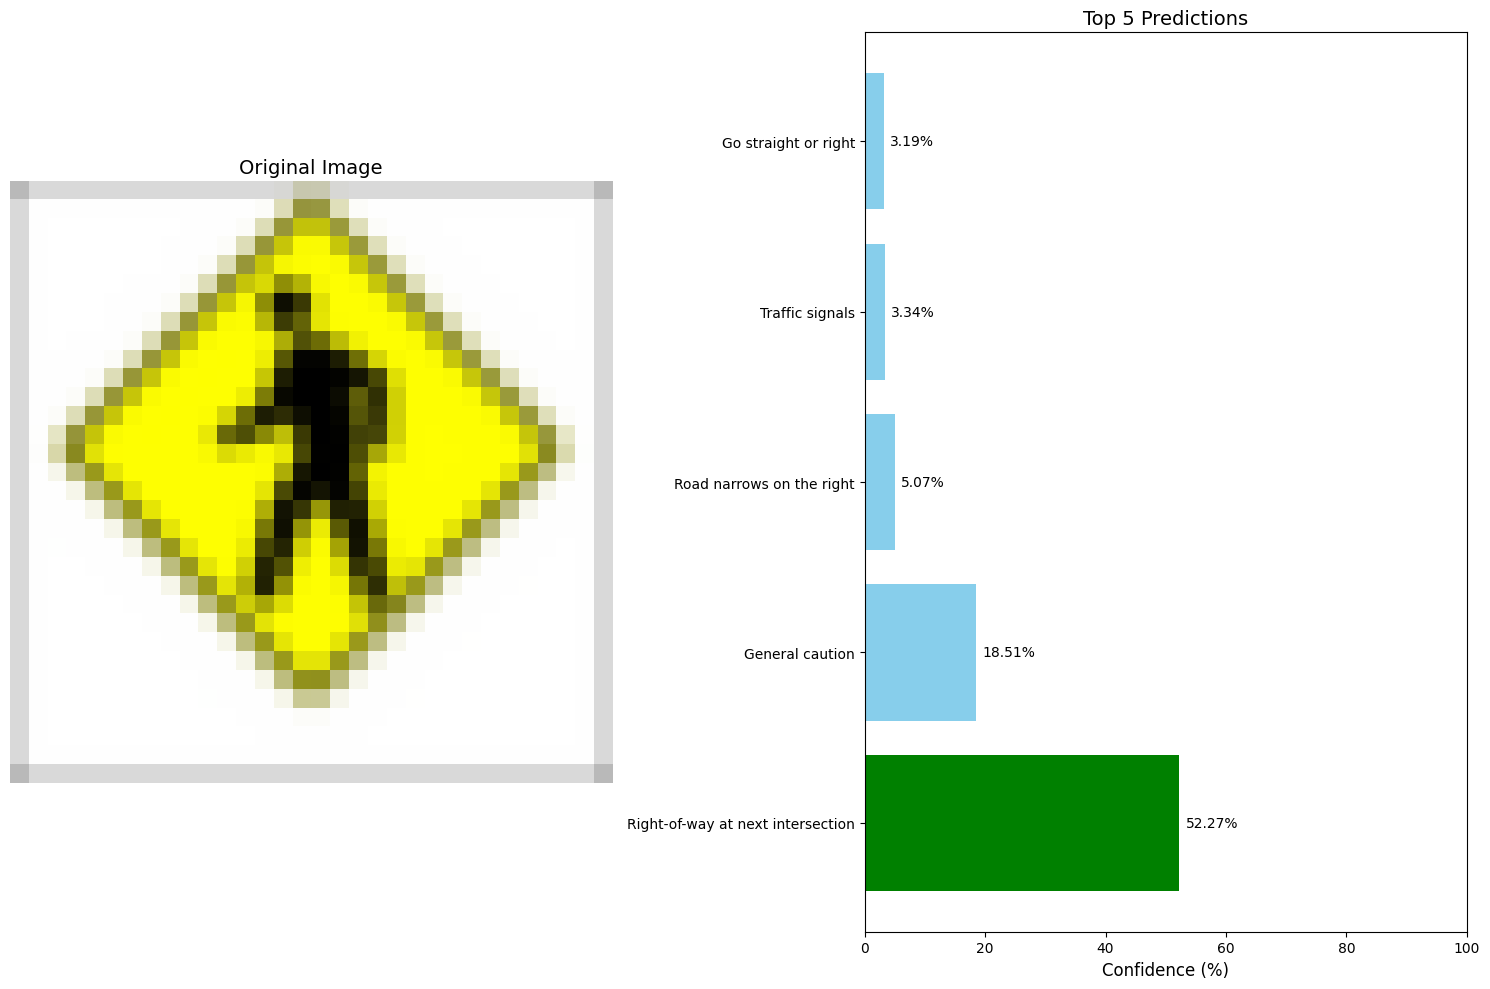


✅ PREDICTION RESULTS - Uploaded Image
1. Right-of-way at next intersection
   → Confidence: 52.27%
   → ✅ This is the model's top prediction
2. General caution
   → Confidence: 18.51%
3. Road narrows on the right
   → Confidence: 5.07%
4. Traffic signals
   → Confidence: 3.34%
5. Go straight or right
   → Confidence: 3.19%

💡 Interpretation:
   The model has LOW CONFIDENCE - this prediction may be unreliable

✅ Inference demo completed!


In [21]:
# ## 8. Inference: Test Model on Uploaded Images



print("🔍 Loading required components for inference...")

# %% [code]
def load_or_create_model():
    """Check for saved models and load the best one available"""
    # Check for best saved model from training
    if os.path.exists('best_traffic_sign_model.keras'):
        print("✅ Loading best saved model from training...")
        return keras.models.load_model('best_traffic_sign_model.keras')

    # Check for final saved model
    elif os.path.exists('final_traffic_sign_model.keras'):
        print("✅ Loading final saved model...")
        return keras.models.load_model('final_traffic_sign_model.keras')

    # If no saved model, check if model variable exists
    elif 'model' in globals():
        print("✅ Using existing model variable...")
        return model

    else:
        print("❌ No model found! Please train a model first.")
        print("💡 Try running the training code before inference")
        return None

# %% [code]
def preprocess_single_image(image_path=None, is_url=False, is_uploaded=False, uploaded_file=None):
    """Preprocess a single image to match model input requirements"""
    # Load image from path, URL, or uploaded file
    try:
        if is_uploaded and uploaded_file is not None:
            # Handle uploaded file in Colab - CRITICAL FIX: Wrap bytes in BytesIO
            img = io.imread(BytesIO(uploaded_file))
        elif is_url:
            # Handle URL
            response = requests.get(image_path)
            img = io.imread(BytesIO(response.content))
        else:
            # Handle local file path
            img = io.imread(image_path)
    except Exception as e:
        print(f"❌ Error loading image: {str(e)}")
        return None

    # Convert to RGB if it's grayscale
    if len(img.shape) == 2:
        img = np.stack((img,)*3, axis=-1)

    # Ensure 3 channels (RGB)
    if img.shape[2] > 3:
        img = img[:, :, :3]

    # Resize to 32x32 (model input size)
    img = transform.resize(img, (32, 32),
                         mode='constant',
                         anti_aliasing=True)

    # Convert to grayscale (Y channel of YCbCr)
    img_gray = 0.299 * img[:, :, 0] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]

    # Scale to [0, 1]
    img_gray = (img_gray / 255.).astype(np.float32)

    # Apply histogram equalization
    img_eq = exposure.equalize_adapthist(img_gray)

    # Add batch and channel dimensions
    img_eq = np.expand_dims(img_eq, axis=(0, -1))

    return img_eq, img  # Return preprocessed and original for display

# %% [code]
def get_class_names():
    """Get traffic sign class names for better interpretation"""
    # German Traffic Sign Class Names (43 classes)
    class_names = [
        "Speed limit (20km/h)", "Speed limit (30km/h)", "Speed limit (50km/h)",
        "Speed limit (60km/h)", "Speed limit (70km/h)", "Speed limit (80km/h)",
        "End of speed limit (80km/h)", "Speed limit (100km/h)", "Speed limit (120km/h)",
        "No passing", "No passing for vehicles over 3.5 metric tons",
        "Right-of-way at next intersection", "Priority road", "Yield", "Stop",
        "No vehicles", "Vehicles over 3.5 metric tons prohibited", "No entry",
        "General caution", "Dangerous curve to the left", "Dangerous curve to the right",
        "Double curve", "Bumpy road", "Slippery road", "Road narrows on the right",
        "Road work", "Traffic signals", "Pedestrians", "Children crossing",
        "Bicycles crossing", "Beware of ice/snow", "Wild animals crossing",
        "End of all speed and passing limits", "Turn right ahead", "Turn left ahead",
        "Ahead only", "Go straight or right", "Go straight or left", "Keep right",
        "Keep left", "Roundabout mandatory", "End of no passing",
        "End of no passing by vehicles over 3.5 metric tons"
    ]
    return class_names

# %% [code]
def predict_traffic_sign(image_path=None, is_url=False, is_uploaded=False, uploaded_file=None):
    """Predict traffic sign class for a given image"""
    # 1. Load model
    model = load_or_create_model()
    if model is None:
        return

    # 2. Preprocess image
    if is_uploaded and uploaded_file is not None:
        print(f"\n🔍 Processing uploaded image...")
        result = preprocess_single_image(
            None, is_url, is_uploaded, uploaded_file
        )
        if result is None:
            return
        processed_img, original_img = result
    else:
        print(f"\n🔍 Processing image: {image_path}")
        result = preprocess_single_image(
            image_path, is_url, is_uploaded, None
        )
        if result is None:
            return
        processed_img, original_img = result

    # 3. Make prediction
    print("📊 Running model inference...")
    predictions = model.predict(processed_img)[0]

    # 4. Get top predictions
    top_5_idx = np.argsort(predictions)[::-1][:5]
    class_names = get_class_names()

    # 5. Display results
    plt.figure(figsize=(15, 10))

    # Display original image
    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title('Original Image', fontsize=14)
    plt.axis('off')

    # Display prediction results
    plt.subplot(1, 2, 2)
    y_pos = np.arange(len(top_5_idx))

    # Create color mapping (green for top prediction, others in blue)
    colors = ['green' if i == 0 else 'skyblue' for i in range(len(top_5_idx))]

    plt.barh(y_pos, predictions[top_5_idx] * 100, color=colors, align='center')
    plt.yticks(y_pos, [class_names[i] for i in top_5_idx])
    plt.xlabel('Confidence (%)', fontsize=12)
    plt.title('Top 5 Predictions', fontsize=14)
    plt.xlim(0, 100)

    # Add confidence percentages on bars
    for i, v in enumerate(predictions[top_5_idx] * 100):
        plt.text(v + 1, i, f"{v:.2f}%", color='black', va='center')

    plt.tight_layout()
    plt.savefig('prediction_results.png', dpi=120, bbox_inches='tight')
    plt.show()

    # Print detailed results
    print("\n" + "="*50)
    if is_uploaded:
        print(f"✅ PREDICTION RESULTS - Uploaded Image")
    elif is_url:
        print(f"✅ PREDICTION RESULTS - URL Image")
    else:
        print(f"✅ PREDICTION RESULTS - {os.path.basename(image_path)}")
    print("="*50)

    for i, idx in enumerate(top_5_idx):
        confidence = predictions[idx] * 100
        print(f"{i+1}. {class_names[idx]}")
        print(f"   → Confidence: {confidence:.2f}%")
        if i == 0:
            print("   → ✅ This is the model's top prediction")

    print("\n💡 Interpretation:")
    if predictions[top_5_idx[0]] > 0.9:
        print("   The model is VERY CONFIDENT in this prediction")
    elif predictions[top_5_idx[0]] > 0.7:
        print("   The model is CONFIDENT in this prediction")
    else:
        print("   The model has LOW CONFIDENCE - this prediction may be unreliable")

    return top_5_idx[0], predictions[top_5_idx[0]]

# %% [code]
def upload_and_predict():
    """Let user upload an image directly in Colab and predict"""
    print("\n📤 Upload your traffic sign image...")

    try:
        # Check if we're in Google Colab
        from google.colab import files
        print("💡 Detected Google Colab environment - using file upload widget")

        # Create upload button
        uploaded = files.upload()

        if not uploaded:
            print("❌ No file was uploaded")
            return

        # Get the first uploaded file
        for filename, data in uploaded.items():
            print(f"✅ Uploaded {filename}")

            # Process the uploaded file - CRITICAL FIX: Pass the bytes data directly
            predict_traffic_sign(is_uploaded=True, uploaded_file=data)
            return

    except ImportError:
        # Not in Colab - fallback to file path
        print("💡 Not in Google Colab - falling back to file path input")
        image_path = input("📁 Enter path to your image: ").strip()
        if os.path.exists(image_path):
            predict_traffic_sign(image_path)
        else:
            print(f"❌ File not found: {image_path}")

# %% [code]
def test_with_sample_images():
    """Test the model with sample images from the test set"""
    print("🧪 Testing with sample images from test set...")

    # Check if we have test data available
    if 'X_test' not in globals() or 'y_test' not in globals() or len(X_test) == 0:
        print("⚠️ Test data not available. Loading a few examples...")

        # Try to load directly from dataset if variables aren't defined
        if os.path.exists("GTSRB/Final_Test/Images/"):
            test_dir = "GTSRB/Final_Test/Images/"
            test_images = [f for f in os.listdir(test_dir) if f.endswith('.ppm')][:3]

            for img_file in test_images:
                img_path = os.path.join(test_dir, img_file)
                predict_traffic_sign(img_path)
        else:
            print("❌ Cannot find test images. Please ensure dataset is properly loaded.")
    else:
        # Pick 3 random test images
        for _ in range(3):
            idx = np.random.randint(0, len(X_test))
            true_class = np.argmax(y_test[idx])

            # Create a temporary image file for demonstration
            temp_path = f"temp_test_{idx}.png"
            plt.imsave(temp_path, X_test[idx].squeeze(), cmap='gray')

            # Get class name
            class_names = get_class_names()
            print(f"\n🎯 TRUE CLASS: {class_names[true_class]} (Class {true_class})")

            # Make prediction
            pred_class, confidence = predict_traffic_sign(temp_path)

            # Clean up
            os.remove(temp_path)

            # Show if correct
            is_correct = pred_class == true_class
            print(f"\n{'✅' if is_correct else '❌'} Prediction {'CORRECT' if is_correct else 'INCORRECT'}")
            if not is_correct:
                print(f"   → True class was: {class_names[true_class]}")

# %% [code]
def test_with_real_world_images():
    """Test the model with real-world traffic sign images from URLs"""
    print("\n🌍 Testing with real-world traffic sign images...")

    # Example URLs of traffic signs (you can replace these with your own)
    example_urls = [
        "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3b/Road_sign_274.svg/1200px-Road_sign_274.svg.png",
        "https://upload.wikimedia.org/wikipedia/commons/thumb/9/92/Road_sign_264.svg/1200px-Road_sign_264.svg.png",
        "https://upload.wikimedia.org/wikipedia/commons/thumb/d/d4/Road_sign_276.svg/1200px-Road_sign_276.svg.png"
    ]

    class_names = get_class_names()

    for url in example_urls:
        print(f"\n🌐 Testing URL: {url}")
        predict_traffic_sign(url, is_url=True)

# %% [code]
# Main execution flow
print("\n🚀 Starting traffic sign recognition demo...")

# First check if model is available
model = load_or_create_model()
if model is not None:
    print("\n📌 Available testing options:")
    print("   1. Test with sample images from the test set")
    print("   2. Test with real-world traffic sign images")
    print("   3. Upload your own image (Colab only)")

    choice = input("\n👉 Enter your choice (1/2/3): ").strip()

    if choice == '1':
        test_with_sample_images()

    elif choice == '2':
        test_with_real_world_images()

    elif choice == '3':
        upload_and_predict()

    else:
        print("❌ Invalid choice. Please run this cell again and select 1, 2, or 3.")

    print("\n✅ Inference demo completed!")
else:
    print("\n💡 Tip: To use this demo, first train a model or load a pre-trained one.")
    print("   You can run the training code from earlier sections")